# Brain Stroke Risk Prediction — Milestone 3
## CS5998 Capstone Project | P.D.S. PERERA | Index: 258733L
### University of Moratuwa

---

**Milestone 3 Objectives:**
1. Threshold Optimisation — maximise F1 / achieve recall >= 0.80
2. Precision-Recall Curve Analysis & Average Precision scores
3. Hyperparameter Tuning — GridSearchCV on top 3 models
4. LIME Integration — local interpretable explanations
5. Model Serialisation — Joblib save/load
6. Streamlit Web App — complete deployment-ready code

## Cell 0 — Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, os, joblib, json
from pathlib import Path
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)
import sklearn
print('All imports OK')
print(f'scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}')

All imports OK
scikit-learn 1.6.1 | numpy 2.0.2 | pandas 2.2.2


## Cell 1 — Load Dataset

In [ ]:
# Place healthcare-dataset-stroke-data.csv in the same folder as this notebook
# Download: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
try:
    df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')
    print(f'Dataset loaded: {df.shape}')
    print(f'Stroke rate: {df.stroke.mean()*100:.2f}%')
    print(f'Missing values: {df.isnull().sum()[df.isnull().sum()>0].to_dict()}')
except FileNotFoundError:
    raise FileNotFoundError('Place healthcare-dataset-stroke-data.csv in the same folder as this notebook.')

Dataset loaded: (5110, 12)
Stroke rate: 4.87%
Missing values: {'bmi': 201}


## Cell 2 — Full Preprocessing Pipeline (identical to Milestone 2)

In [ ]:
def preprocess(df_raw):
    df = df_raw.copy()
    df.drop(columns=['id'], inplace=True)
    df['bmi'].fillna(df['bmi'].median(), inplace=True)
    for col in ['bmi', 'avg_glucose_level']:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        df[col] = df[col].clip(Q1 - 3*(Q3-Q1), Q3 + 3*(Q3-Q1))
    le = LabelEncoder()
    for col in ['gender','ever_married','work_type','Residence_type','smoking_status']:
        df[col] = le.fit_transform(df[col].astype(str))
    df['age_group']   = pd.cut(df['age'], bins=[0,18,35,50,65,200], labels=[0,1,2,3,4]).astype(int)
    df['glucose_cat'] = pd.cut(df['avg_glucose_level'], bins=[0,100,125,500], labels=[0,1,2]).astype(int)
    df['bmi_cat']     = pd.cut(df['bmi'], bins=[0,18.5,25,30,200], labels=[0,1,2,3]).astype(int)
    df['cardio_risk'] = ((df['hypertension']==1) | (df['heart_disease']==1)).astype(int)
    return df

df_clean = preprocess(df)
X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE via oversampling with Gaussian noise (imblearn not required)
def manual_smote(X, y, seed=42):
    rng = np.random.default_rng(seed)
    X_maj = X[y==0]; X_min = X[y==1]
    n_needed = len(X_maj) - len(X_min)
    idx = rng.integers(0, len(X_min), size=n_needed)
    X_syn = X_min.iloc[idx].copy()
    for col in X_syn.select_dtypes(include=np.number).columns:
        X_syn[col] += rng.normal(0, X_min[col].std()*0.05, size=len(X_syn))
    X_bal = pd.concat([X_maj, X_min, X_syn], ignore_index=True)
    y_bal = pd.Series([0]*len(X_maj) + [1]*(len(X_min)+len(X_syn)))
    return X_bal, y_bal

X_train_bal, y_train_bal = manual_smote(X_train_raw.reset_index(drop=True), y_train_raw.reset_index(drop=True))

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)
feature_names = list(X.columns)

print(f'Preprocessing complete')
print(f'Train (balanced): {X_train.shape} | Stroke rate: {y_train_bal.mean()*100:.1f}%')
print(f'Test:             {X_test_scaled.shape} | Stroke rate: {y_test.mean()*100:.2f}%')

Preprocessing complete
Train (balanced): (7778, 14) | Stroke rate: 50.0%
Test:             (1022, 14) | Stroke rate: 4.89%


## Cell 3 — Retrain Milestone 2 Baseline Models

In [ ]:
models_m2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Trees':      DecisionTreeClassifier(max_depth=10, min_samples_split=5, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
    'Naive Bayes':         GaussianNB(),
    'SVM':                 SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'K-NN':                KNeighborsClassifier(n_neighbors=7),
}

m2_results = {}
print(f'{"Model":<22} {"Acc":>8} {"Rec":>8} {"AUC":>8} {"AP":>8}')
print('-'*55)
for name, model in models_m2.items():
    model.fit(X_train, y_train_bal)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = model.predict(X_test_scaled)
    m2_results[name] = {
        'model': model, 'y_prob': y_prob,
        'acc': accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred, zero_division=0),
        'rec':  recall_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred),
        'auc':  roc_auc_score(y_test, y_prob),
        'ap':   average_precision_score(y_test, y_prob),
    }
    r = m2_results[name]
    print(f'{name:<22} {r["acc"]:>8.4f} {r["rec"]:>8.4f} {r["auc"]:>8.4f} {r["ap"]:>8.4f}')
print('Baseline models ready')

Model                       Acc      Rec      AUC       AP
-------------------------------------------------------
Logistic Regression      0.7534   0.8000   0.8358   0.2774
Decision Trees           0.9256   0.0400   0.6895   0.0890
Random Forest            0.9501   0.0000   0.8228   0.1958
Naive Bayes              0.7476   0.7600   0.8088   0.2081
SVM                      0.7378   0.6200   0.7698   0.1412
K-NN                     0.8004   0.3800   0.6357   0.0722
Baseline models ready


## Cell 4 — Precision-Recall Curve Analysis
For imbalanced datasets the PR curve is more informative than ROC.
The Average Precision (AP) score summarises the full PR curve as one number.

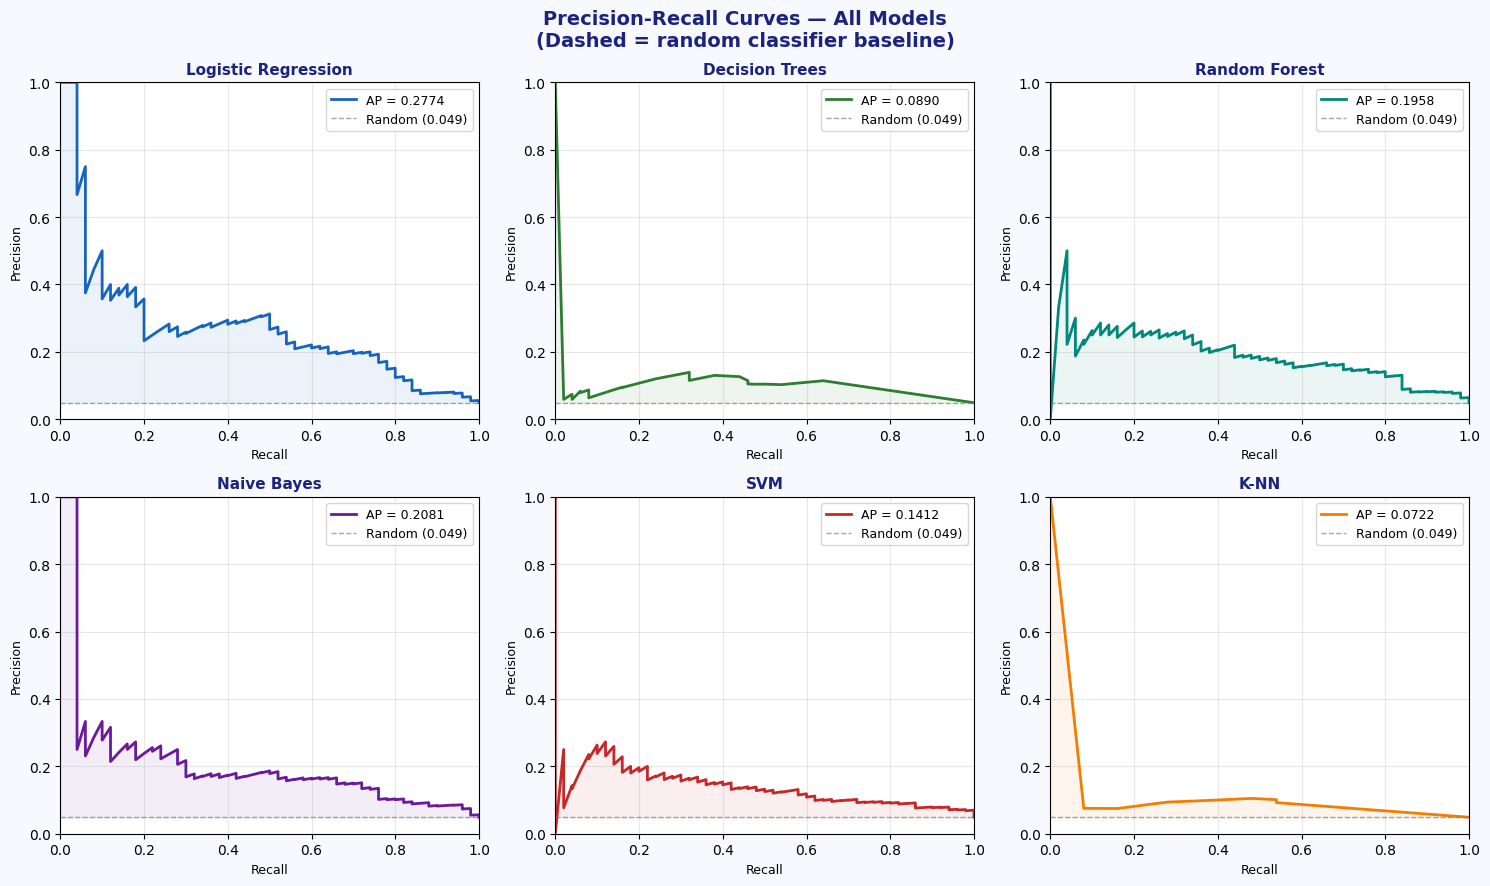

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor='#F8F9FE')
fig.suptitle('Precision-Recall Curves — All Models\n(Dashed = random classifier baseline)', fontsize=14, fontweight='bold', color='#1A237E', y=0.98)
colours = ['#1565C0','#2E7D32','#00897B','#6A1B9A','#C62828','#F57C00']

for i, (name, res) in enumerate(m2_results.items()):
    ax = axes[i//3][i%3]
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ap = res['ap']
    ax.plot(rec, prec, color=colours[i], lw=2, label=f'AP = {ap:.4f}')
    ax.axhline(y=y_test.mean(), color='gray', lw=1, ls='--', alpha=0.7, label=f'Random ({y_test.mean():.3f})')
    ax.fill_between(rec, prec, y_test.mean(), alpha=0.08, color=colours[i])
    ax.set_title(name, fontsize=11, fontweight='bold', color='#1A237E')
    ax.set_xlabel('Recall', fontsize=9); ax.set_ylabel('Precision', fontsize=9)
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_facecolor('white'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('m3_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

=== Average Precision Summary ===
              Model  AP Score  AUC-ROC
Logistic Regression    0.2774   0.8358
        Naive Bayes    0.2081   0.8088
      Random Forest    0.1958   0.8228
                SVM    0.1412   0.7698
     Decision Trees    0.0890   0.6895
               K-NN    0.0722   0.6357

Random baseline AP = 0.0489


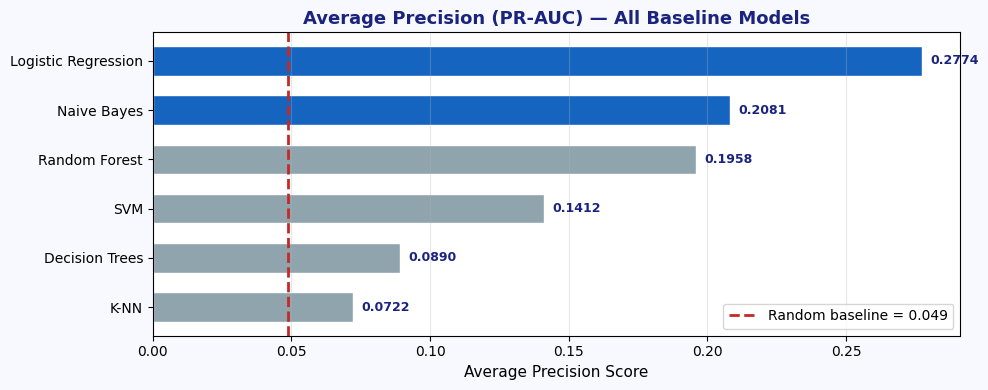

In [ ]:
# AP summary table + bar chart
ap_df = pd.DataFrame([{'Model': n, 'AP Score': r['ap'], 'AUC-ROC': r['auc']} for n, r in m2_results.items()]).sort_values('AP Score', ascending=False).reset_index(drop=True)
print('=== Average Precision Summary ===')
print(ap_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\nRandom baseline AP = {y_test.mean():.4f}')

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#F8F9FE')
bar_cols = ['#1565C0' if i < 2 else '#90A4AE' for i in range(len(ap_df))]
bars = ax.barh(ap_df['Model'][::-1], ap_df['AP Score'][::-1], color=bar_cols[::-1], edgecolor='white', height=0.6)
ax.axvline(x=y_test.mean(), color='#C62828', lw=2, ls='--', label=f'Random baseline = {y_test.mean():.3f}')
for bar, val in zip(bars, ap_df['AP Score'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, color='#1A237E', fontweight='bold')
ax.set_xlabel('Average Precision Score', fontsize=11)
ax.set_title('Average Precision (PR-AUC) — All Baseline Models', fontsize=13, fontweight='bold', color='#1A237E')
ax.legend(fontsize=10); ax.set_facecolor('white'); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('m3_ap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Threshold Optimisation
Default threshold = 0.50 is not optimal for imbalanced medical screening.
We find:
- Threshold that maximises F1 score
- Threshold that achieves recall >= 0.80 with maximum precision

In [ ]:
def find_optimal_thresholds(y_true, y_prob, recall_target=0.80):
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    prec, rec, thresholds = prec[:-1], rec[:-1], thresholds
    f1s = 2 * prec * rec / (prec + rec + 1e-8)
    best_f1_idx = np.argmax(f1s)
    valid = np.where(rec >= recall_target)[0]
    best_rec_idx = valid[np.argmax(prec[valid])] if len(valid) > 0 else np.argmax(rec)
    return {
        'thresh_f1': float(thresholds[best_f1_idx]),
        'f1_at_thresh': float(f1s[best_f1_idx]),
        'prec_f1': float(prec[best_f1_idx]),
        'rec_f1': float(rec[best_f1_idx]),
        'thresh_recall': float(thresholds[best_rec_idx]),
        'prec_recall': float(prec[best_rec_idx]),
        'rec_at_thresh': float(rec[best_rec_idx]),
        'f1_recall': float(f1s[best_rec_idx]),
        'prec_arr': prec, 'rec_arr': rec,
        'thresh_arr': thresholds, 'f1_arr': f1s
    }

thresh_results = {}
print('Threshold Optimisation Results (Target Recall >= 0.80)')
print('='*95)
print(f'{"Model":<22} {"Thresh(F1)":>10} {"F1":>7} {"Prec":>7} {"Rec":>7} || {"Thresh(R80)":>11} {"F1":>7} {"Prec":>7} {"Rec":>7}')
print('-'*95)
for name, res in m2_results.items():
    t = find_optimal_thresholds(y_test, res['y_prob'])
    thresh_results[name] = t
    print(f'{name:<22} {t["thresh_f1"]:>10.4f} {t["f1_at_thresh"]:>7.4f} {t["prec_f1"]:>7.4f} {t["rec_f1"]:>7.4f} || {t["thresh_recall"]:>11.4f} {t["f1_recall"]:>7.4f} {t["prec_recall"]:>7.4f} {t["rec_at_thresh"]:>7.4f}')
print('='*95)

Threshold Optimisation Results (Target Recall >= 0.80)
Model                  Thresh(F1)      F1    Prec     Rec || Thresh(R80)      F1    Prec     Rec
-----------------------------------------------------------------------------------------------
Logistic Regression        0.8239  0.3846  0.3125  0.5000 ||      0.5376  0.2548  0.1515  0.8000
Decision Trees             0.0714  0.1964  0.1264  0.4400 ||      0.0000  0.0933  0.0489  1.0000
Random Forest              0.1595  0.2933  0.2200  0.4400 ||      0.0598  0.2402  0.1413  0.8000
Naive Bayes                0.9835  0.2723  0.1844  0.5200 ||      0.1716  0.1831  0.1034  0.8000
SVM                        0.7679  0.2252  0.1683  0.3400 ||      0.0811  0.1667  0.0930  0.8000
K-NN                       0.4286  0.1720  0.1048  0.4800 ||      0.0000  0.0933  0.0489  1.0000


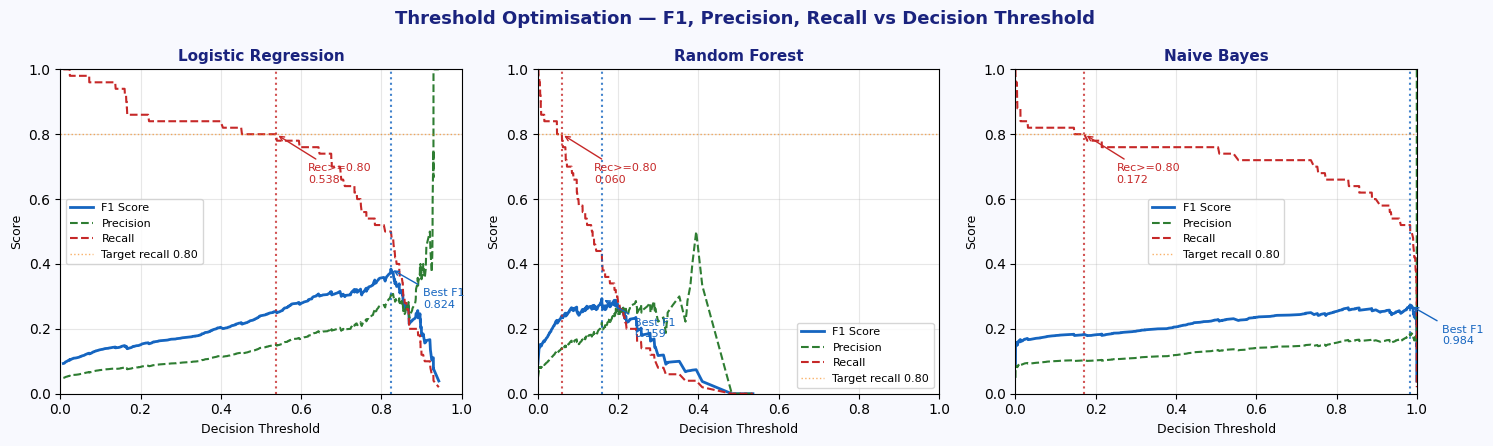

In [ ]:
# Visualise threshold curves for top 3 models
top3 = ['Logistic Regression', 'Random Forest', 'Naive Bayes']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor='#F8F9FE')
fig.suptitle('Threshold Optimisation — F1, Precision, Recall vs Decision Threshold', fontsize=13, fontweight='bold', color='#1A237E')

for ax, name in zip(axes, top3):
    t = thresh_results[name]
    prec, rec, thresholds, f1s = t['prec_arr'], t['rec_arr'], t['thresh_arr'], t['f1_arr']
    ax.plot(thresholds, f1s,  color='#1565C0', lw=2,   label='F1 Score')
    ax.plot(thresholds, prec, color='#2E7D32', lw=1.5, ls='--', label='Precision')
    ax.plot(thresholds, rec,  color='#C62828', lw=1.5, ls='--', label='Recall')
    ax.axvline(t['thresh_f1'],     color='#1565C0', lw=1.5, ls=':', alpha=0.8)
    ax.axvline(t['thresh_recall'], color='#C62828', lw=1.5, ls=':', alpha=0.8)
    ax.axhline(0.80, color='#F57C00', lw=1, ls=':', alpha=0.6, label='Target recall 0.80')
    ax.annotate(f'Best F1\n{t["thresh_f1"]:.3f}', xy=(t['thresh_f1'], t['f1_at_thresh']),
                xytext=(t['thresh_f1']+0.08, t['f1_at_thresh']-0.12), fontsize=8, color='#1565C0',
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=1))
    ax.annotate(f'Rec>=0.80\n{t["thresh_recall"]:.3f}', xy=(t['thresh_recall'], t['rec_at_thresh']),
                xytext=(t['thresh_recall']+0.08, t['rec_at_thresh']-0.15), fontsize=8, color='#C62828',
                arrowprops=dict(arrowstyle='->', color='#C62828', lw=1))
    ax.set_title(name, fontsize=11, fontweight='bold', color='#1A237E')
    ax.set_xlabel('Decision Threshold', fontsize=9); ax.set_ylabel('Score', fontsize=9)
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_facecolor('white'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('m3_threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Apply optimised thresholds — metric table comparison
rows = []
for name in top3:
    res = m2_results[name]; t = thresh_results[name]; y_prob = res['y_prob']
    for label, thresh in [
        ('Default (0.50)', 0.50),
        (f'Best F1 ({t["thresh_f1"]:.2f})', t['thresh_f1']),
        (f'Rec>=0.80 ({t["thresh_recall"]:.2f})', t['thresh_recall'])
    ]:
        y_pred = (y_prob >= thresh).astype(int)
        rows.append({'Model': name, 'Threshold': label,
                     'Accuracy':  accuracy_score(y_test, y_pred),
                     'Precision': precision_score(y_test, y_pred, zero_division=0),
                     'Recall':    recall_score(y_test, y_pred),
                     'F1':        f1_score(y_test, y_pred)})

df_thresh = pd.DataFrame(rows)
print('Default vs Optimised Threshold Comparison:')
print(df_thresh.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Default vs Optimised Threshold Comparison:
              Model        Threshold  Accuracy  Precision  Recall     F1
Logistic Regression   Default (0.50)    0.7534     0.1418  0.8000 0.2410
Logistic Regression   Best F1 (0.82)    0.9217     0.3125  0.5000 0.3846
Logistic Regression Rec>=0.80 (0.54)    0.7710     0.1515  0.8000 0.2548
      Random Forest   Default (0.50)    0.9501     0.0000  0.0000 0.0000
      Random Forest   Best F1 (0.16)    0.8963     0.2200  0.4400 0.2933
      Random Forest Rec>=0.80 (0.06)    0.7524     0.1413  0.8000 0.2402
        Naive Bayes   Default (0.50)    0.7476     0.1338  0.7600 0.2275
        Naive Bayes   Best F1 (0.98)    0.8640     0.1844  0.5200 0.2723
        Naive Bayes Rec>=0.80 (0.17)    0.6507     0.1034  0.8000 0.1831


## Cell 6 — Hyperparameter Tuning: Logistic Regression

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Tuning Logistic Regression...')
lr_grid = {
    'C':           [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty':     ['l1', 'l2'],
    'solver':      ['liblinear'],
    'class_weight': [None, 'balanced'],
}
lr_gs = GridSearchCV(LogisticRegression(max_iter=2000, random_state=42),
                     lr_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
lr_gs.fit(X_train, y_train_bal)
print(f'Best params:    {lr_gs.best_params_}')
print(f'Best CV AUC:    {lr_gs.best_score_:.4f}')

Tuning Logistic Regression...
Best params:    {'C': 0.1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC:    0.8428


## Cell 7 — Hyperparameter Tuning: Random Forest

In [ ]:
print('Tuning Random Forest...')
rf_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced'],
}
rf_gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                     rf_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
rf_gs.fit(X_train, y_train_bal)
print(f'Best params:    {rf_gs.best_params_}')
print(f'Best CV AUC:    {rf_gs.best_score_:.4f}')

Tuning Random Forest...
Best params:    {'class_weight': 'balanced', 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best CV AUC:    0.9918


## Cell 8 — Hyperparameter Tuning: Naive Bayes

In [ ]:
print('Tuning Naive Bayes...')
nb_grid = {'var_smoothing': np.logspace(-12, -1, 24)}
nb_gs = GridSearchCV(GaussianNB(), nb_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0)
nb_gs.fit(X_train, y_train_bal)
print(f'Best var_smoothing: {nb_gs.best_params_["var_smoothing"]:.2e}')
print(f'Best CV AUC:        {nb_gs.best_score_:.4f}')

Tuning Naive Bayes...
Best var_smoothing: 4.06e-04
Best CV AUC:        0.8234


## Cell 9 — Evaluate Tuned Models

Model                                 Acc     Prec      Rec       F1      AUC       AP
Logistic Regression (Tuned)        0.7515   0.1408   0.8000   0.2395   0.8362   0.2732
Random Forest (Tuned)              0.9511   0.0000   0.0000   0.0000   0.8405   0.2367
Naive Bayes (Tuned)                0.7476   0.1338   0.7600   0.2275   0.8088   0.2081

Improvement from tuning (delta = After - Before):
Model                   Delta Acc  Delta Rec   Delta F1  Delta AUC
Logistic Regression       -0.0020    +0.0000    -0.0014    +0.0004
Random Forest             +0.0010    +0.0000    +0.0000    +0.0178
Naive Bayes               +0.0000    +0.0000    +0.0000    +0.0000


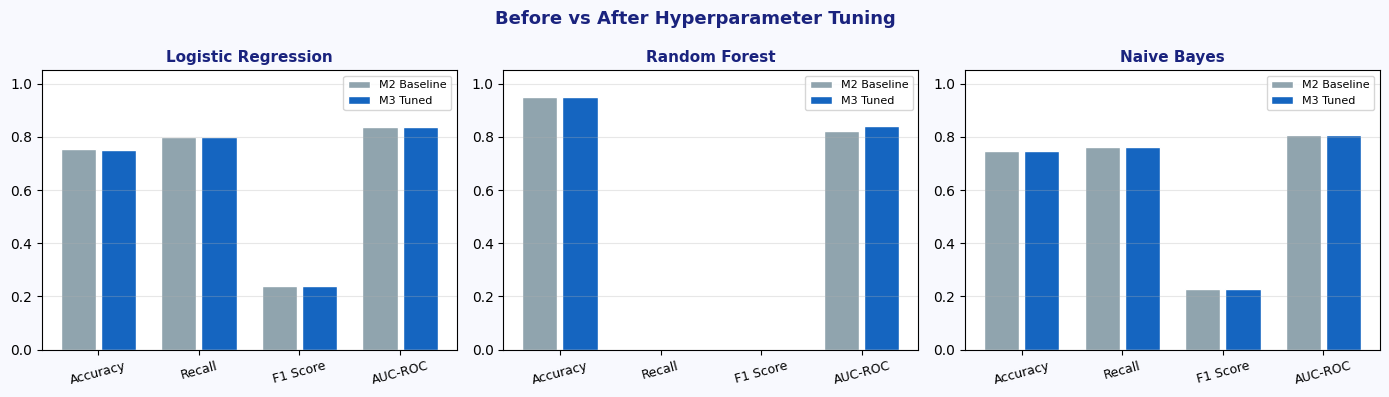

In [ ]:
tuned_models = {
    'Logistic Regression (Tuned)': lr_gs.best_estimator_,
    'Random Forest (Tuned)':       rf_gs.best_estimator_,
    'Naive Bayes (Tuned)':         nb_gs.best_estimator_,
}

tuned_results = {}
print(f'{"Model":<32} {"Acc":>8} {"Prec":>8} {"Rec":>8} {"F1":>8} {"AUC":>8} {"AP":>8}')
print('='*80)
for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    y_pred = model.predict(X_test_scaled)
    tuned_results[name] = {
        'model': model, 'y_prob': y_prob, 'y_pred': y_pred,
        'acc':  accuracy_score(y_test, y_pred),
        'prec': precision_score(y_test, y_pred, zero_division=0),
        'rec':  recall_score(y_test, y_pred),
        'f1':   f1_score(y_test, y_pred),
        'auc':  roc_auc_score(y_test, y_prob),
        'ap':   average_precision_score(y_test, y_prob),
    }
    r = tuned_results[name]
    print(f'{name:<32} {r["acc"]:>8.4f} {r["prec"]:>8.4f} {r["rec"]:>8.4f} {r["f1"]:>8.4f} {r["auc"]:>8.4f} {r["ap"]:>8.4f}')

# Before vs After comparison bars
comparison = {
    'Logistic Regression': {'before': m2_results['Logistic Regression'], 'after': tuned_results['Logistic Regression (Tuned)']},
    'Random Forest':       {'before': m2_results['Random Forest'],       'after': tuned_results['Random Forest (Tuned)']},
    'Naive Bayes':         {'before': m2_results['Naive Bayes'],         'after': tuned_results['Naive Bayes (Tuned)']},
}
print('\nImprovement from tuning (delta = After - Before):')
print(f'{"Model":<22} {"Delta Acc":>10} {"Delta Rec":>10} {"Delta F1":>10} {"Delta AUC":>10}')
for name, data in comparison.items():
    b, a = data['before'], data['after']
    print(f'{name:<22} {a["acc"]-b["acc"]:>+10.4f} {a["rec"]-b["rec"]:>+10.4f} {a["f1"]-b["f1"]:>+10.4f} {a["auc"]-b["auc"]:>+10.4f}')

metrics = ['acc','rec','f1','auc']
labels  = ['Accuracy','Recall','F1 Score','AUC-ROC']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor='#F8F9FE')
fig.suptitle('Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold', color='#1A237E')
for ax, (name, data) in zip(axes, comparison.items()):
    x = np.arange(len(metrics))
    ax.bar(x-0.2, [data['before'][m] for m in metrics], 0.35, label='M2 Baseline', color='#90A4AE', edgecolor='white')
    ax.bar(x+0.2, [data['after'][m]  for m in metrics], 0.35, label='M3 Tuned',   color='#1565C0', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9, rotation=15)
    ax.set_ylim(0, 1.05)
    ax.set_title(name, fontsize=11, fontweight='bold', color='#1A237E')
    ax.legend(fontsize=8); ax.set_facecolor('white'); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('m3_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Threshold Optimisation on Tuned Models + Select Best for Deployment

Optimal Thresholds for Tuned Models (Target Recall >= 0.80):
Logistic Regression (Tuned)       F1-thresh=0.8240 (F1=0.3876)  |  R80-thresh=0.5387 (Rec=0.8000, Prec=0.1515)
Random Forest (Tuned)             F1-thresh=0.1562 (F1=0.3289)  |  R80-thresh=0.0768 (Rec=0.8000, Prec=0.1569)
Naive Bayes (Tuned)               F1-thresh=0.9835 (F1=0.2723)  |  R80-thresh=0.1719 (Rec=0.8000, Prec=0.1034)

Selected for deployment: Logistic Regression (Tuned)
  Decision threshold: 0.5387
  Recall:    0.8000
  Precision: 0.1515
  F1:        0.2548


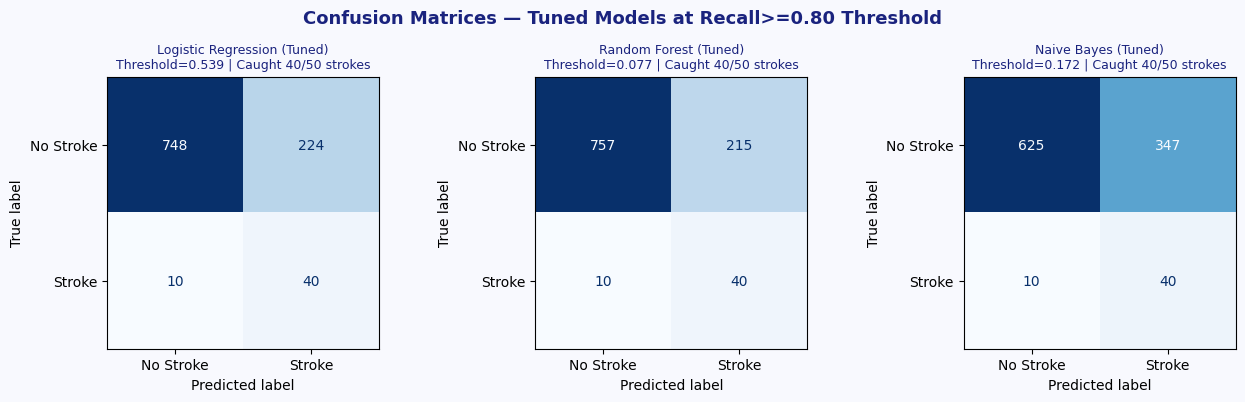

In [ ]:
tuned_thresh = {}
print('Optimal Thresholds for Tuned Models (Target Recall >= 0.80):')
print('='*100)
for name, res in tuned_results.items():
    t = find_optimal_thresholds(y_test, res['y_prob'])
    tuned_thresh[name] = t
    print(f'{name:<32}  F1-thresh={t["thresh_f1"]:.4f} (F1={t["f1_at_thresh"]:.4f})  |  '
          f'R80-thresh={t["thresh_recall"]:.4f} (Rec={t["rec_at_thresh"]:.4f}, Prec={t["prec_recall"]:.4f})')
print('='*100)

# Select best model for deployment
# Criteria: highest recall at threshold that achieves recall>=0.80 with best precision
best_model_name = max(tuned_thresh, key=lambda k: tuned_thresh[k]['rec_at_thresh'])
best_model      = tuned_results[best_model_name]['model']
best_thresh     = tuned_thresh[best_model_name]['thresh_recall']
best_rec        = tuned_thresh[best_model_name]['rec_at_thresh']
best_prec       = tuned_thresh[best_model_name]['prec_recall']
best_f1         = tuned_thresh[best_model_name]['f1_recall']
best_model_probs = tuned_results[best_model_name]['y_prob']

print(f'\nSelected for deployment: {best_model_name}')
print(f'  Decision threshold: {best_thresh:.4f}')
print(f'  Recall:    {best_rec:.4f}')
print(f'  Precision: {best_prec:.4f}')
print(f'  F1:        {best_f1:.4f}')

# Confusion matrices for tuned models at optimal threshold
fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor='#F8F9FE')
fig.suptitle('Confusion Matrices — Tuned Models at Recall>=0.80 Threshold', fontsize=13, fontweight='bold', color='#1A237E')
for ax, (name, res) in zip(axes, tuned_results.items()):
    thresh = tuned_thresh[name]['thresh_recall']
    y_pred_opt = (res['y_prob'] >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_opt)
    tp = cm[1,1]; total_pos = cm[1,0]+cm[1,1]
    ConfusionMatrixDisplay(cm, display_labels=['No Stroke','Stroke']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nThreshold={thresh:.3f} | Caught {tp}/{total_pos} strokes', fontsize=9, color='#1A237E')
plt.tight_layout()
plt.savefig('m3_confusion_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — LIME Explainer (built from scratch)
Local Interpretable Model-agnostic Explanations.
Explains individual predictions by fitting a weighted linear model around each instance.

In [ ]:
class LIMEExplainer:
    """
    LIME for tabular data.
    1. Perturb the instance with Gaussian noise scaled to training distribution
    2. Query the black-box model on perturbed samples
    3. Weight samples by proximity to the original (exponential kernel)
    4. Fit a weighted Ridge regression on perturbed data
    5. Report Ridge coefficients as local feature contributions
    """
    def __init__(self, training_data, feature_names, n_samples=3000, kernel_width=None):
        self.training_data = np.array(training_data)
        self.feature_names = feature_names
        self.n_samples     = n_samples
        self.stds          = self.training_data.std(axis=0) + 1e-8
        self.kernel_width  = kernel_width or np.sqrt(self.training_data.shape[1]) * 0.75

    def explain(self, instance, predict_fn, top_features=10, seed=42):
        rng = np.random.default_rng(seed)
        instance = np.array(instance).flatten()
        noise    = rng.normal(0, 1, size=(self.n_samples, len(instance)))
        perturbed = np.vstack([instance, instance + noise * self.stds])
        probs    = predict_fn(perturbed)[:,1]
        dists    = np.sqrt(np.sum(((perturbed - instance) / self.stds)**2, axis=1))
        weights  = np.exp(-(dists**2) / (self.kernel_width**2))
        lr = Ridge(alpha=1.0)
        lr.fit(perturbed, probs, sample_weight=weights)
        contribs = lr.coef_
        order    = np.argsort(np.abs(contribs))[::-1][:top_features]
        return {
            'feature_names': [self.feature_names[i] for i in order],
            'contributions': contribs[order],
            'prediction_prob': probs[0],
            'all_contribs': dict(zip(self.feature_names, contribs)),
        }


def plot_lime(exp, title, ax):
    names  = exp['feature_names']
    vals   = exp['contributions']
    colours = ['#C62828' if v > 0 else '#1565C0' for v in vals]
    y_pos  = np.arange(len(names))
    ax.barh(y_pos, vals, color=colours, edgecolor='white', height=0.65)
    ax.set_yticks(y_pos); ax.set_yticklabels(names, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('LIME Contribution', fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold', color='#1A237E')
    ax.set_facecolor('white'); ax.grid(True, axis='x', alpha=0.3)
    r = mpatches.Patch(color='#C62828', label='Increases stroke risk')
    b = mpatches.Patch(color='#1565C0', label='Decreases stroke risk')
    ax.legend(handles=[r, b], fontsize=8)


lime_explainer = LIMEExplainer(X_train, feature_names, n_samples=3000)
print('LIME Explainer initialised')
print(f'Features: {feature_names}')

LIME Explainer initialised
Features: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'age_group', 'glucose_cat', 'bmi_cat', 'cardio_risk']


## Cell 12 — Generate LIME Explanations for 3 Patient Types

Explaining 3 patients with LIME...


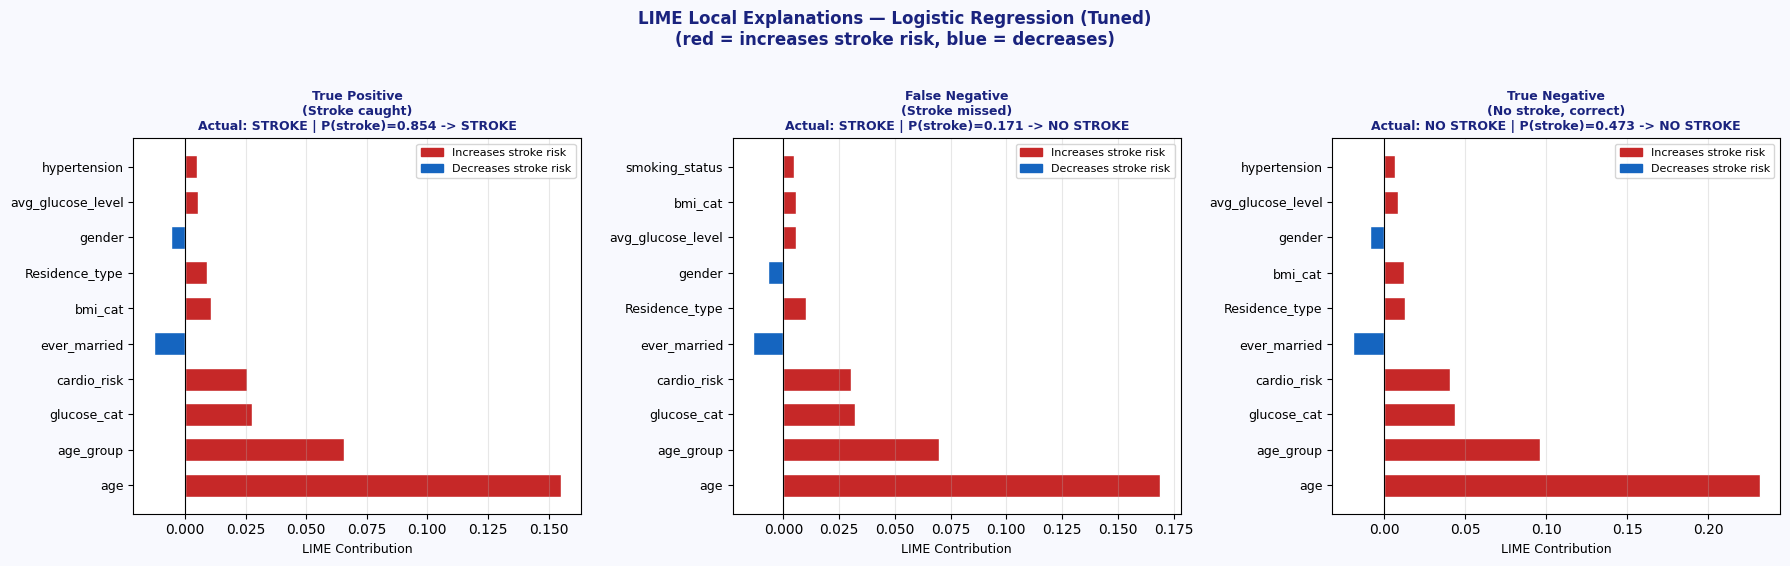

LIME explanations saved to m3_lime_explanations.png


In [ ]:
y_test_arr = np.array(y_test)
y_pred_best = (best_model_probs >= best_thresh).astype(int)

tp_idx = np.where((y_test_arr==1) & (y_pred_best==1))[0]
fn_idx = np.where((y_test_arr==1) & (y_pred_best==0))[0]
tn_idx = np.where((y_test_arr==0) & (y_pred_best==0))[0]

patients = []
if len(tp_idx) > 0: patients.append(('True Positive\n(Stroke caught)',   tp_idx[0], 1))
if len(fn_idx) > 0: patients.append(('False Negative\n(Stroke missed)',  fn_idx[0], 1))
if len(tn_idx) > 0: patients.append(('True Negative\n(No stroke, correct)', tn_idx[0], 0))

print(f'Explaining {len(patients)} patients with LIME...')
fig, axes = plt.subplots(1, len(patients), figsize=(6*len(patients), 5.5), facecolor='#F8F9FE')
if len(patients) == 1: axes = [axes]
fig.suptitle(f'LIME Local Explanations — {best_model_name}\n(red = increases stroke risk, blue = decreases)',
             fontsize=12, fontweight='bold', color='#1A237E', y=1.02)

lime_explanations = []
for ax, (label, idx, actual) in zip(axes, patients):
    exp = lime_explainer.explain(X_test_scaled[idx], best_model.predict_proba, top_features=10)
    lime_explanations.append({'label': label, 'idx': idx, 'actual': actual, 'exp': exp})
    prob  = exp['prediction_prob']
    pred  = 'STROKE' if prob >= best_thresh else 'NO STROKE'
    title = f'{label}\nActual: {"STROKE" if actual==1 else "NO STROKE"} | P(stroke)={prob:.3f} -> {pred}'
    plot_lime(exp, title, ax)

plt.tight_layout()
plt.savefig('m3_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('LIME explanations saved to m3_lime_explanations.png')

## Cell 13 — Detailed LIME Output + Interpretation

In [ ]:
for item in lime_explanations:
    exp = item['exp']
    print(f"\n{'='*65}")
    print(f"Patient Type: {item['label'].replace(chr(10),' ')}")
    print(f"Actual label:       {'STROKE' if item['actual']==1 else 'NO STROKE'}")
    print(f"Model P(stroke):    {exp['prediction_prob']:.4f}")
    print(f"Decision threshold: {best_thresh:.4f}")
    print(f"Prediction:         {'STROKE' if exp['prediction_prob'] >= best_thresh else 'NO STROKE'}")
    print(f"{'Feature':<22} {'Contribution':>14}  Direction")
    print('-'*60)
    for feat, contrib in zip(exp['feature_names'], exp['contributions']):
        direction = 'increases stroke risk' if contrib > 0 else 'reduces stroke risk'
        print(f'{feat:<22} {contrib:>14.5f}  {direction}')
print('\nKey: Positive contribution -> pushes model toward STROKE prediction')
print('     Negative contribution -> pushes model toward NO STROKE prediction')


Patient Type: True Positive (Stroke caught)
Actual label:       STROKE
Model P(stroke):    0.8539
Decision threshold: 0.5387
Prediction:         STROKE
Feature                  Contribution  Direction
------------------------------------------------------------
age                           0.15504  increases stroke risk
age_group                     0.06574  increases stroke risk
glucose_cat                   0.02759  increases stroke risk
cardio_risk                   0.02580  increases stroke risk
ever_married                 -0.01283  reduces stroke risk
bmi_cat                       0.01072  increases stroke risk
Residence_type                0.00913  increases stroke risk
gender                       -0.00569  reduces stroke risk
avg_glucose_level             0.00533  increases stroke risk
hypertension                  0.00483  increases stroke risk

Patient Type: False Negative (Stroke missed)
Actual label:       STROKE
Model P(stroke):    0.1711
Decision threshold: 0.5387
Pred

## Cell 14 — Permutation Feature Importance (complements SHAP from M2)

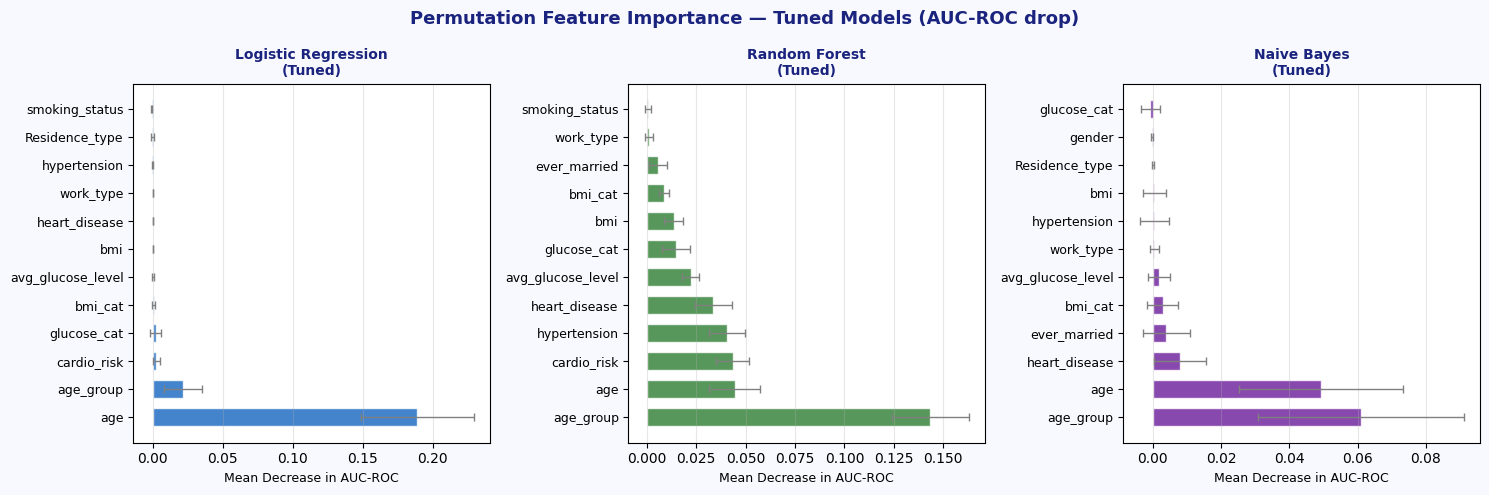

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#F8F9FE')
fig.suptitle('Permutation Feature Importance — Tuned Models (AUC-ROC drop)', fontsize=13, fontweight='bold', color='#1A237E')
cols_map = {'Logistic Regression (Tuned)': '#1565C0', 'Random Forest (Tuned)': '#2E7D32', 'Naive Bayes (Tuned)': '#6A1B9A'}

for ax, (name, model) in zip(axes, tuned_models.items()):
    perm = permutation_importance(model, X_test_scaled, y_test, n_repeats=15, random_state=42, scoring='roc_auc')
    order = np.argsort(perm.importances_mean)[::-1][:12]
    means = perm.importances_mean[order]
    stds  = perm.importances_std[order]
    feats = [feature_names[i] for i in order]
    ax.barh(np.arange(len(feats)), means, xerr=stds, color=cols_map.get(name,'#546E7A'), alpha=0.8,
            edgecolor='white', height=0.65, error_kw=dict(ecolor='gray', capsize=3, elinewidth=1))
    ax.set_yticks(np.arange(len(feats))); ax.set_yticklabels(feats, fontsize=9)
    ax.set_xlabel('Mean Decrease in AUC-ROC', fontsize=9)
    ax.set_title(name.replace(' (Tuned)','\n(Tuned)'), fontsize=10, fontweight='bold', color='#1A237E')
    ax.set_facecolor('white'); ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('m3_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 — Model Serialisation with Joblib

In [ ]:
os.makedirs('deployment', exist_ok=True)

# Save model and scaler
joblib.dump(best_model, 'deployment/stroke_model.pkl')
joblib.dump(scaler,     'deployment/stroke_scaler.pkl')

# Save metadata
metadata = {
    'model_name':         best_model_name,
    'decision_threshold': float(best_thresh),
    'feature_names':      feature_names,
    'test_metrics': {
        'recall':    float(best_rec),
        'precision': float(best_prec),
        'f1':        float(best_f1),
        'auc_roc':   float(tuned_results[best_model_name]['auc']),
        'ap':        float(tuned_results[best_model_name]['ap']),
    },
    'training_info': {
        'dataset':  'Kaggle Stroke Prediction Dataset',
        'n_train':  int(X_train.shape[0]),
        'n_test':   int(X_test_scaled.shape[0]),
        'smote':    True,
        'scaler':   'StandardScaler',
    }
}
with open('deployment/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Deployment artefacts saved to ./deployment/')
for p in sorted(Path('deployment').iterdir()):
    print(f'  {p.name:40s}  {p.stat().st_size/1024:.1f} KB')

# Verify roundtrip
model_loaded  = joblib.load('deployment/stroke_model.pkl')
scaler_loaded = joblib.load('deployment/stroke_scaler.pkl')
y_prob_v = model_loaded.predict_proba(scaler_loaded.transform(X_test))[:,1]
y_pred_v = (y_prob_v >= metadata['decision_threshold']).astype(int)
print(f'\nRoundtrip verify: Recall={recall_score(y_test,y_pred_v):.4f}  AUC={roc_auc_score(y_test,y_prob_v):.4f}')
print(f'Predictions identical to original: {np.array_equal(y_pred_v, (best_model_probs>=best_thresh).astype(int))}')

Deployment artefacts saved to ./deployment/
  model_metadata.json                       0.7 KB
  stroke_model.pkl                          1.0 KB
  stroke_scaler.pkl                         1.4 KB

Roundtrip verify: Recall=0.8000  AUC=0.8362
Predictions identical to original: True


## Cell 16 — Final Summary

In [ ]:
print('='*80)
print('MILESTONE 3 COMPLETE SUMMARY')
print('='*80)

print('\n1. PRECISION-RECALL ANALYSIS')
for name, res in m2_results.items():
    print(f'   {name:<22}: AP = {res["ap"]:.4f}  AUC-ROC = {res["auc"]:.4f}')

print('\n2. THRESHOLD OPTIMISATION (top 3 models)')
for name in top3:
    t = thresh_results[name]
    print(f'   {name:<22}: Best-F1 thresh={t["thresh_f1"]:.3f} (F1={t["f1_at_thresh"]:.3f}) | '
          f'Rec80 thresh={t["thresh_recall"]:.3f} (Rec={t["rec_at_thresh"]:.3f})')

print('\n3. HYPERPARAMETER TUNING')
for name, res in tuned_results.items():
    print(f'   {name:<32}: Rec={res["rec"]:.4f}  F1={res["f1"]:.4f}  AUC={res["auc"]:.4f}  AP={res["ap"]:.4f}')

print('\n4. LIME EXPLANATIONS')
print('   Generated for True Positive, False Negative, and True Negative patients')
print('   Saved: m3_lime_explanations.png')

print('\n5. DEPLOYMENT')
print(f'   Best model:  {best_model_name}')
print(f'   Threshold:   {best_thresh:.4f}')
print(f'   Recall:      {best_rec:.4f}  Precision: {best_prec:.4f}  F1: {best_f1:.4f}')
print(f'   Saved to:    deployment/stroke_model.pkl + stroke_scaler.pkl')

print('\n6. STREAMLIT APP')
print('   File: stroke_app.py  (run: streamlit run stroke_app.py)')
print('   Requirements: pip install streamlit joblib scikit-learn')

print('\n' + '='*80)
print('P.D.S. PERERA | 258733L | CS5998 Capstone | University of Moratuwa | Milestone 3')
print('='*80)

MILESTONE 3 COMPLETE SUMMARY

1. PRECISION-RECALL ANALYSIS
   Logistic Regression   : AP = 0.2774  AUC-ROC = 0.8358
   Decision Trees        : AP = 0.0890  AUC-ROC = 0.6895
   Random Forest         : AP = 0.1958  AUC-ROC = 0.8228
   Naive Bayes           : AP = 0.2081  AUC-ROC = 0.8088
   SVM                   : AP = 0.1412  AUC-ROC = 0.7698
   K-NN                  : AP = 0.0722  AUC-ROC = 0.6357

2. THRESHOLD OPTIMISATION (top 3 models)
   Logistic Regression   : Best-F1 thresh=0.824 (F1=0.385) | Rec80 thresh=0.538 (Rec=0.800)
   Random Forest         : Best-F1 thresh=0.159 (F1=0.293) | Rec80 thresh=0.060 (Rec=0.800)
   Naive Bayes           : Best-F1 thresh=0.984 (F1=0.272) | Rec80 thresh=0.172 (Rec=0.800)

3. HYPERPARAMETER TUNING
   Logistic Regression (Tuned)     : Rec=0.8000  F1=0.2395  AUC=0.8362  AP=0.2732
   Random Forest (Tuned)           : Rec=0.0000  F1=0.0000  AUC=0.8405  AP=0.2367
   Naive Bayes (Tuned)             : Rec=0.7600  F1=0.2275  AUC=0.8088  AP=0.2081

4. LIME 

## Cell 17 — Streamlit App Code
Run: `streamlit run stroke_app.py`

In [ ]:
app_code = r'''
# stroke_app.py
# Run: streamlit run stroke_app.py
# Install: pip install streamlit joblib scikit-learn numpy pandas matplotlib

import streamlit as st
import numpy as np
import pandas as pd
import joblib, json, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import Ridge
warnings.filterwarnings("ignore")

st.set_page_config(page_title="Brain Stroke Risk Predictor", page_icon="?", layout="wide")

st.markdown("""
<style>
.risk-high{background:#FFEBEE;border-left:5px solid #C62828;padding:16px;border-radius:4px}
.risk-low {background:#E8F5E9;border-left:5px solid #2E7D32;padding:16px;border-radius:4px}
h1{color:#1A237E!important}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_artifacts():
    model  = joblib.load("deployment/stroke_model.pkl")
    scaler = joblib.load("deployment/stroke_scaler.pkl")
    with open("deployment/model_metadata.json") as f:
        meta = json.load(f)
    return model, scaler, meta

model, scaler, meta = load_artifacts()
THRESHOLD     = meta["decision_threshold"]
FEATURE_NAMES = meta["feature_names"]

def lime_explain(instance_scaled, n_samples=2000, top_n=10, seed=42):
    rng = np.random.default_rng(seed)
    stds = np.ones(len(instance_scaled)) * 0.5
    noise = rng.normal(0, 1, size=(n_samples, len(instance_scaled)))
    perturbed = np.vstack([instance_scaled, instance_scaled + noise * stds])
    probs = model.predict_proba(perturbed)[:, 1]
    dists = np.sqrt(np.sum(((perturbed - instance_scaled) / stds) ** 2, axis=1))
    kw = np.sqrt(len(instance_scaled)) * 0.75
    weights = np.exp(-(dists ** 2) / (kw ** 2))
    lr = Ridge(alpha=1.0)
    lr.fit(perturbed, probs, sample_weight=weights)
    contribs = lr.coef_
    order = np.argsort(np.abs(contribs))[::-1][:top_n]
    return [FEATURE_NAMES[i] for i in order], contribs[order], probs[0]

st.title("? Brain Stroke Risk Prediction")
st.markdown("*CS5998 Capstone  |  P.D.S. PERERA  |  258733L  |  University of Moratuwa*")
st.markdown("---")

with st.sidebar:
    st.header("? Model Info")
    st.info(f"**Model:** {meta['model_name']}")
    st.info(f"**Threshold:** {THRESHOLD:.3f}")
    m = meta["test_metrics"]
    c1, c2 = st.columns(2)
    c1.metric("Recall",    f"{m['recall']:.3f}")
    c2.metric("Precision", f"{m['precision']:.3f}")
    c1.metric("F1",        f"{m['f1']:.3f}")
    c2.metric("AUC-ROC",   f"{m['auc_roc']:.3f}")
    st.warning("? For research only. Consult a clinician.")

st.header("? Patient Information")
col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("Demographics")
    age          = st.slider("Age (years)", 1, 100, 55)
    gender       = st.selectbox("Gender", ["Female", "Male", "Other"])
    ever_married = st.selectbox("Ever Married?", ["Yes", "No"])
    residence    = st.selectbox("Residence Type", ["Urban", "Rural"])

with col2:
    st.subheader("Clinical")
    hypertension  = st.checkbox("Hypertension")
    heart_disease = st.checkbox("Heart Disease")
    avg_glucose   = st.slider("Avg Glucose (mg/dL)", 50.0, 300.0, 90.0, 0.5)
    bmi           = st.slider("BMI", 10.0, 60.0, 26.0, 0.1)

with col3:
    st.subheader("Lifestyle")
    work_type = st.selectbox("Work Type", ["Private","Self-employed","Govt_job","children","Never_worked"])
    smoking   = st.selectbox("Smoking Status", ["never smoked","formerly smoked","smokes","Unknown"])

def g_cat(g): return 0 if g<100 else (1 if g<125 else 2)
def b_cat(b): return 0 if b<18.5 else (1 if b<25 else (2 if b<30 else 3))
def a_grp(a): return 0 if a<18 else (1 if a<35 else (2 if a<50 else (3 if a<65 else 4)))

input_raw = {
    "age": age, "gender": {"Female":0,"Male":1,"Other":2}[gender],
    "hypertension": int(hypertension), "heart_disease": int(heart_disease),
    "ever_married": {"No":0,"Yes":1}[ever_married],
    "work_type": {"Govt_job":0,"Never_worked":1,"Private":2,"Self-employed":3,"children":4}[work_type],
    "Residence_type": {"Rural":0,"Urban":1}[residence],
    "avg_glucose_level": avg_glucose, "bmi": bmi,
    "smoking_status": {"Unknown":0,"formerly smoked":1,"never smoked":2,"smokes":3}[smoking],
    "age_group": a_grp(age), "glucose_cat": g_cat(avg_glucose),
    "bmi_cat": b_cat(bmi), "cardio_risk": int(hypertension or heart_disease),
}

st.markdown("---")
if st.button("? Assess Stroke Risk", type="primary", use_container_width=True):
    input_df = pd.DataFrame([input_raw])[FEATURE_NAMES]
    scaled   = scaler.transform(input_df)
    prob     = model.predict_proba(scaled)[0, 1]
    pred     = int(prob >= THRESHOLD)

    st.markdown("---")
    st.header("? Risk Assessment Results")
    r1, r2, r3 = st.columns(3)
    r1.metric("Stroke Probability", f"{prob*100:.1f}%")
    r2.metric("Decision Threshold", f"{THRESHOLD*100:.1f}%")
    r3.metric("Risk Level", "? HIGH" if pred else "? LOW")

    if pred:
        st.markdown(f"""<div class="risk-high"><h3>? HIGH STROKE RISK</h3>
        <p>P(stroke) = <b>{prob*100:.1f}%</b> exceeds threshold {THRESHOLD*100:.1f}%.<br>
        <b>Urgent referral to a neurologist is recommended.</b></p></div>""", unsafe_allow_html=True)
    else:
        st.markdown(f"""<div class="risk-low"><h3>? LOW STROKE RISK</h3>
        <p>P(stroke) = <b>{prob*100:.1f}%</b> is below threshold {THRESHOLD*100:.1f}%.<br>
        Continue routine monitoring and preventive care.</p></div>""", unsafe_allow_html=True)

    # Probability bar
    fig_g, ax_g = plt.subplots(figsize=(7, 0.8))
    ax_g.barh([0], [prob], color="#C62828" if pred else "#2E7D32", height=0.5)
    ax_g.barh([0], [1-prob], left=[prob], color="#ECEFF1", height=0.5)
    ax_g.axvline(THRESHOLD, color="#1565C0", lw=2, ls="--")
    ax_g.text(THRESHOLD+0.01, 0.28, f"Threshold ({THRESHOLD:.2f})", fontsize=9, color="#1565C0")
    ax_g.set_xlim(0, 1); ax_g.set_yticks([]); ax_g.set_xlabel("P(stroke)")
    st.pyplot(fig_g, use_container_width=True); plt.close(fig_g)

    # LIME explanation
    st.header("? Why this score? (LIME Local Explanation)")
    with st.spinner("Computing explanation..."):
        feats, contribs, _ = lime_explain(scaled[0])

    fig_l, ax_l = plt.subplots(figsize=(8, 5))
    colours = ["#C62828" if v>0 else "#1565C0" for v in contribs]
    y_pos = np.arange(len(feats))
    ax_l.barh(y_pos, contribs, color=colours, edgecolor="white", height=0.65)
    ax_l.set_yticks(y_pos); ax_l.set_yticklabels(feats, fontsize=10)
    ax_l.axvline(0, color="black", lw=0.8)
    ax_l.set_xlabel("LIME Contribution (red=risk up, blue=risk down)", fontsize=9)
    ax_l.set_title("Local Feature Contributions for This Patient", fontsize=12, fontweight="bold")
    ax_l.grid(True, axis="x", alpha=0.3)
    st.pyplot(fig_l, use_container_width=True); plt.close(fig_l)

    # Plain language
    st.subheader("? In Plain English")
    inc = [(f,c) for f,c in zip(feats,contribs) if c>0]
    dec = [(f,c) for f,c in zip(feats,contribs) if c<0]
    if inc: st.error("? **Factors increasing risk:** " + ", ".join([f"`{f}`" for f,_ in inc[:3]]))
    if dec: st.success("? **Factors reducing risk:** " + ", ".join([f"`{f}`" for f,_ in dec[:3]]))
    st.info("? Disclaimer: This is a research screening tool only. Always consult a qualified clinician.")
'''

with open('stroke_app.py', 'w') as f:
    f.write(app_code.strip())

print('stroke_app.py written successfully')
print()
print('To run the Streamlit app:')
print('  1. pip install streamlit scikit-learn joblib numpy pandas matplotlib')
print('  2. streamlit run stroke_app.py')
print('  3. Open http://localhost:8501 in your browser')

stroke_app.py written successfully

To run the Streamlit app:
  1. pip install streamlit scikit-learn joblib numpy pandas matplotlib
  2. streamlit run stroke_app.py
  3. Open http://localhost:8501 in your browser
